## Resume Screening using Deep Learning

#### Problem Statement :
Automatically classify resumes into job categories using Deep Learning.

#### Goal :
Build a text classification model that predicts job roles from resume content.

In [2]:
import numpy as np
import pandas as pd

# Load dataset
df = pd.read_csv("../data/Resume.csv")

# Show first 5 rows
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
# Dataset shape
df.shape

(2484, 4)

In [4]:
# Column names
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [5]:
df['Category'].value_counts()

# To explore the dataset to understand class distribution and structure.”

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [6]:
# Drop non-important columns from dataset

df = df.drop(['ID','Resume_html'],axis=1)
df

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR
...,...,...
2479,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION
2480,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION
2481,GEEK SQUAD AGENT Professional...,AVIATION
2482,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION


##### "Used a real-world resume dataset containing raw text resumes and job categories.Selected the plain-text resumes and ignored HTML and ID fields to reduce noise before applying deep learning.”

In [7]:
df = df[['Resume_str', 'Category']]
df.columns = ['resume_text', 'category']

df.columns

Index(['resume_text', 'category'], dtype='object')

### Text Cleaning

In [8]:

import re  # Regular Expressions: Used to find and replace patterns in text

def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)         # remove numbers & special chars
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    return text

In [9]:
df['clean_resume'] = df['resume_text'].apply(clean_text)

df[['resume_text', 'clean_resume']].head()

,resume_text,clean_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administratormarketing associate hr adminis...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over years experience in r...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


##### “Applied regex-based text cleaning to normalize resumes by removing noise like URLs, special characters, and casing before feeding them into a deep learning model.”

In [10]:
df.columns

Index(['resume_text', 'category', 'clean_resume'], dtype='object')

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['label'] = le.fit_transform(df['category'])

df[['category', 'label']].head()

,category,label
0,HR,19
1,HR,19
2,HR,19
3,HR,19
4,HR,19


In [12]:
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

In [13]:
# Input features (resume text)
X = df['clean_resume']

# Target labels
y = df['label']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (1987,)
Testing samples: (497,)


### Text Tokenization & Padding

In [16]:
# Text input (X)
texts = df['clean_resume'].values

# Labels (y)
labels = df['label'].values

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

max_len = 200
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

d:\ANACONDA\envs\resume_dl\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [18]:
padded_sequences.shape

(2484, 200)

In [19]:
import numpy as np

print("Unique labels:", np.unique(labels))
print("Number of classes:", len(np.unique(labels)))

Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Number of classes: 24


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [21]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1987, 200)
X_test: (497, 200)
y_train: (1987,)
y_test: (497,)


### DL Model

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [23]:
# Define model parameters

vocab_size = 5000      # Same as tokenizer num_words
embedding_dim = 128    # Size of word vectors
max_len = 200          # Same as padding length
num_classes = 24       # From Step 8.1

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Embedding(input_dim=5000, output_dim=100, input_length=200),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.6),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(24, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 100)          500000    
                                                                 
 bidirectional (Bidirectiona  (None, 128)              84480     
 l)                                                              
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 24)                1560      
                                                        

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [26]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
63/63 [==============================] - 13s 136ms/step - loss: 3.1585 - accuracy: 0.0624 - val_loss: 3.1046 - val_accuracy: 0.2455
Epoch 2/30
63/63 [==============================] - 7s 113ms/step - loss: 2.9626 - accuracy: 0.1782 - val_loss: 2.6048 - val_accuracy: 0.4044
Epoch 3/30
63/63 [==============================] - 8s 124ms/step - loss: 2.5120 - accuracy: 0.3110 - val_loss: 2.0304 - val_accuracy: 0.5272
Epoch 4/30
63/63 [==============================] - 8s 122ms/step - loss: 1.9758 - accuracy: 0.4620 - val_loss: 1.5709 - val_accuracy: 0.6217
Epoch 5/30
63/63 [==============================] - 8s 124ms/step - loss: 1.6036 - accuracy: 0.5677 - val_loss: 1.3123 - val_accuracy: 0.6680
Epoch 6/30
63/63 [==============================] - 8s 128ms/step - loss: 1.3184 - accuracy: 0.6301 - val_loss: 1.1876 - val_accuracy: 0.6962
Epoch 7/30
63/63 [==============================] - 8s 125ms/step - loss: 1.1088 - accuracy: 0.6960 - val_loss: 1.1418 - val_accuracy: 0.7062
Epoch

In [27]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.8590840697288513
Final Validation Accuracy: 0.6941649913787842


In [28]:
from sklearn.metrics import classification_report,accuracy_score

y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

print('Accuracy',accuracy_score(y_test,y_pred_classes))
print('Classification Report\n',classification_report(y_test, y_pred_classes))

16/16 [==============================] - 2s 47ms/step
Accuracy 0.6921529175050302
Classification Report
               precision    recall  f1-score   support

           0       0.89      1.00      0.94        24
           1       0.69      0.83      0.75        24
           2       0.75      0.23      0.35        13
           3       0.15      0.11      0.12        19
           4       0.22      0.19      0.21        21
           5       0.00      0.00      0.00         7
           6       0.44      0.46      0.45        24
           7       0.30      0.26      0.28        23
           8       0.00      0.00      0.00         4
           9       0.71      1.00      0.83        24
          10       0.95      0.83      0.89        24
          11       0.69      0.91      0.78        22
          12       0.85      0.96      0.90        23
          13       0.91      0.95      0.93        21
          14       0.62      0.53      0.57        19
          15       0.86      1

d:\ANACONDA\envs\resume_dl\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ANACONDA\envs\resume_dl\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ANACONDA\envs\resume_dl\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


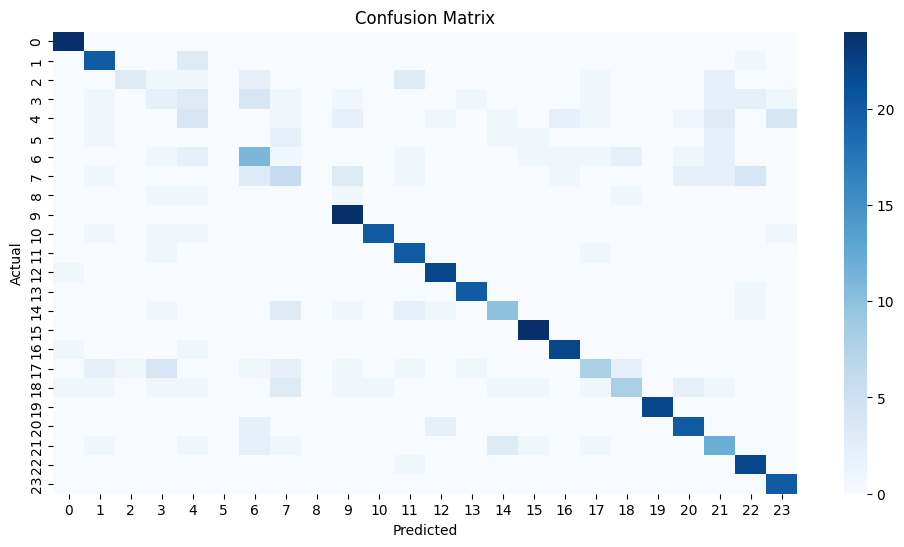

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(12,6))
sns.heatmap(cm, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
y_pred_prob = model.predict(X_test)
y_pred = y_pred_prob.argmax(axis=1)

16/16 [==============================] - 1s 37ms/step


In [33]:
from sklearn.metrics import classification_report

print('Classification Report\n',classification_report(y_test, y_pred))

Classification Report
               precision    recall  f1-score   support

           0       0.89      1.00      0.94        24
           1       0.69      0.83      0.75        24
           2       0.75      0.23      0.35        13
           3       0.15      0.11      0.12        19
           4       0.22      0.19      0.21        21
           5       0.00      0.00      0.00         7
           6       0.44      0.46      0.45        24
           7       0.30      0.26      0.28        23
           8       0.00      0.00      0.00         4
           9       0.71      1.00      0.83        24
          10       0.95      0.83      0.89        24
          11       0.69      0.91      0.78        22
          12       0.85      0.96      0.90        23
          13       0.91      0.95      0.93        21
          14       0.62      0.53      0.57        19
          15       0.86      1.00      0.92        24
          16       0.85      0.92      0.88        24
    

d:\ANACONDA\envs\resume_dl\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ANACONDA\envs\resume_dl\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ANACONDA\envs\resume_dl\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[24,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 20,  0,  0,  3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  1,  0],
       [ 0,  0,  3,  1,  1,  0,  2,  0,  0,  0,  0,  3,  0,  0,  0,  0,
         0,  1,  0,  0,  0,  2,  0,  0],
       [ 0,  1,  0,  2,  3,  0,  4,  1,  0,  1,  0,  0,  0,  1,  0,  0,
         0,  1,  0,  0,  0,  2,  2,  1],
       [ 0,  1,  0,  0,  4,  0,  0,  1,  0,  2,  0,  0,  1,  0,  1,  0,
         2,  1,  0,  0,  1,  3,  0,  4],
       [ 0,  1,  0,  0,  0,  0,  0,  2,  0,  0,  0,  0,  0,  0,  1,  1,
         0,  0,  0,  0,  0,  2,  0,  0],
       [ 0,  0,  0,  1,  2,  0, 11,  1,  0,  0,  0,  1,  0,  0,  0,  1,
         1,  1,  2,  0,  1,  2,  0,  0],
       [ 0,  1,  0,  0,  0,  0,  3,  6,  0,  3,  0,  1,  0,  0,  0,  0,
         1,  0,  0,  0,  2,  2,  4,  0],
       [ 0,  0,  0,  1,  1,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,
         0,  0,  1,  0, 

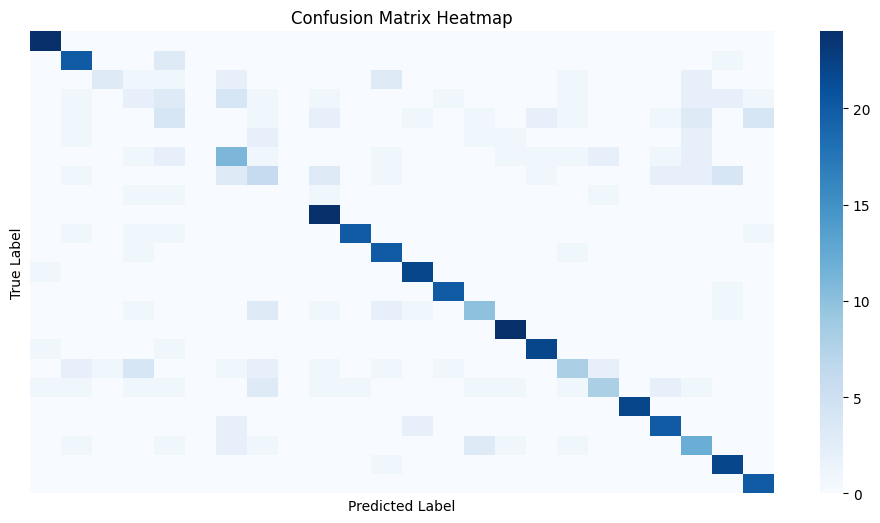

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [37]:
label_mapping = dict(zip(df['label'], df['category']))
label_mapping

{19: 'HR',
 13: 'DESIGNER',
 20: 'INFORMATION-TECHNOLOGY',
 23: 'TEACHER',
 1: 'ADVOCATE',
 9: 'BUSINESS-DEVELOPMENT',
 18: 'HEALTHCARE',
 17: 'FITNESS',
 2: 'AGRICULTURE',
 8: 'BPO',
 22: 'SALES',
 12: 'CONSULTANT',
 14: 'DIGITAL-MEDIA',
 5: 'AUTOMOBILE',
 10: 'CHEF',
 16: 'FINANCE',
 3: 'APPAREL',
 15: 'ENGINEERING',
 0: 'ACCOUNTANT',
 11: 'CONSTRUCTION',
 21: 'PUBLIC-RELATIONS',
 7: 'BANKING',
 4: 'ARTS',
 6: 'AVIATION'}

In [38]:
import re

def clean_resume_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [39]:
def predict_resume_category(resume_text):
    cleaned = clean_resume_text(resume_text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=max_len)
    
    prediction = model.predict(padded)
    predicted_label = prediction.argmax(axis=1)[0]
    
    return label_mapping[predicted_label]

In [40]:
sample_resume = """
Experienced data scientist skilled in Python, machine learning,
deep learning, NLP, data analysis, and model deployment.
"""

predict_resume_category(sample_resume)

1/1 [==============================] - 0s 46ms/step


'BUSINESS-DEVELOPMENT'